# Leiden algorithm

In this notebook communities are created using the Leiden algorithm.

The Leiden algorithm was performed with the maximum community size capped at 5,000 unique software. This constraint produced 70641communities with a modularity score of 0.2956. The resulting size distribution differs from the unconstrained run: the 100 largest communities each reach the maximum of 5,000 unique software, after which community size drops off sharply, tapering to communities of only around 20 unique software by the 150th largest community. This constrained run is the one used going forward.

1. [Notebook Setup](#setup)
2. [Leiden Algorithm](#leiden)
3. [Metrics of the communities](#metrics)
4. [Attaching classifications to the communities](#classify)

<a id='setup'></a>

## Notebook setup
required packages and directory specifications
The notebook assumes that the dataset files are stored in a folder `data` that sits as the same level as the `notebooks` directory. The assumed directory structure is the following:

- `notebooks`
-  `data` 
    - `open_alex_matches`
        - matches.csv.gz
    - `occurence_graph`
        - graph_joblib.pkl.gz
    - `leiden`
        - metrics.txt
        - community_summary.csv.gz

In [2]:
import pandas as pd
import numpy as np
import json
from tqdm import tqdm
from pathlib import Path
import plotly.express as px
import igraph as ig
from pathlib import Path
import joblib
import pickle, gzip
import leidenalg
import ast
from itertools import combinations
from sklearn.metrics.cluster import normalized_mutual_info_score
import clustering_mi as cmi


pd.set_option('max_colwidth', 1000)

In [ ]:
# step 01_extraction_partioned.ipynb
ROOT_DISAMBIGUATED_CLASSIFICATION_DIR = '../data/open_alex_matches'

matches_df = pd.read_csv(ROOT_DISAMBIGUATED_CLASSIFICATION_DIR + '/matches.csv.gz', engine = 'python', compression="gzip")

In [4]:
# version 2025aug Oct 29, 2025. zenedo: 10.5281/zenodo.17442025
# retrieving classification tables
ROOT_CLASSIFICATION_DIR = '../data/classification_openalex_2025/'
macro_cluster_main_field_path = ROOT_CLASSIFICATION_DIR + 'macro_cluster_main_field.tsv'
main_field_path = ROOT_CLASSIFICATION_DIR + 'main_field.tsv'

macro_cluster_main_field_df = pd.read_csv(macro_cluster_main_field_path, sep = '\\t', engine = 'python')
main_field_df = pd.read_csv(main_field_path, sep = '\\t', engine = 'python')

In [5]:
# load graph using joblib
from pathlib import Path
out_dir = Path("../data/occurence_graph")
out_dir.mkdir(parents=True, exist_ok=True)
import joblib
import pickle, gzip

g = joblib.load(out_dir / "graph_joblib.pkl.gz")

<a id='leiden'></a>
### Leiden Algorithm

In [ ]:
seed = 42069
n_runs = 10
rng = np.random.default_rng(seed)
seeds = rng.integers(0, 100000, size=n_runs).tolist()

def compute_nmi_stability(graph, reference_partition, seeds):
    """
    Compare a reference partition against the random seeds 
    using NMI and CMI which was discussed in
    (https://www.nature.com/articles/s41467-025-66150-8#Abs1).
    :-)
    """
    reference_membership = reference_partition.membership
    nmi_scores = []
    cmi_scores = []
    for seed in seeds:
        p = leidenalg.find_partition(
            graph,
            leidenalg.ModularityVertexPartition,
            n_iterations=-1,
            seed=seed,
            weights='weight',
        )
        nmi_scores.append(normalized_mutual_info_score(reference_membership, p.membership))
        cmi_scores.append(cmi.normalized_mutual_information(reference_membership, p.membership))
    return {
        "nmi_mean": np.mean(nmi_scores),
        "nmi_std":  np.std(nmi_scores),
        "nmi_min":  np.min(nmi_scores),
        "nmi_max":  np.max(nmi_scores),
        "cmi_mean": np.mean(cmi_scores),
        "cmi_std":  np.std(cmi_scores),
        "cmi_min":  np.min(cmi_scores),
        "cmi_max":  np.max(cmi_scores),
    }

# 1: create the Initial partition on the full graph
# 
partition = leidenalg.find_partition(
        g,
        leidenalg.ModularityVertexPartition,
        n_iterations=-1,
        seed=seed,
        weights='weight',
    )

print("Initial Partition")
print(f"Number of communities: {len(partition)}")
print(f"Members: {len(partition.membership)}")
print(partition.summary())
print(f"Modularity: {partition.modularity:.4f}")
print(f"Community sizes: {sorted(partition.sizes(), reverse=True)[:30]}")

initial_modularity = partition.modularity

# The mutual information stability check on initial partition
# Note to self, these are also saved in the community_dataframe_df
initial_nmi = compute_nmi_stability(g, partition, seeds)
print(f"\nInitial Partition NMI Stability (reference: seed)")
print(f"NMI mean: {initial_nmi['nmi_mean']:.4f}")
print(f"NMI std:  {initial_nmi['nmi_std']:.4f}")
print(f"NMI min:  {initial_nmi['nmi_min']:.4f}")
print(f"NMI max:  {initial_nmi['nmi_max']:.4f}")
print(f"CMI mean: {initial_nmi['cmi_mean']:.4f}")
print(f"CMI std:  {initial_nmi['cmi_std']:.4f}")
print(f"CMI min:  {initial_nmi['cmi_min']:.4f}")
print(f"CMI max:  {initial_nmi['cmi_max']:.4f}")

# 2: Separate communities by size
# The communities bigger than the min size are further partioned for a single time. 
min_community_size = 10  

small_communities = [i for i, size in enumerate(partition.sizes()) if size < min_community_size]
large_communities = [i for i, size in enumerate(partition.sizes()) if size >= min_community_size]

print(f"\nCommunities skipping sub-partition (< {min_community_size} members): {len(small_communities)}")
print(f"Communities to sub-partition (>= {min_community_size} members): {len(large_communities)}")

# 3: The Leiden partitions are rerun a single time on the large communities
sub_partitions = {}

for community_id in large_communities:
    community_nodes = [v for v, m in enumerate(partition.membership) if m == community_id]
    subgraph = g.induced_subgraph(community_nodes)

    sub_partition = leidenalg.find_partition(
        subgraph,
        leidenalg.ModularityVertexPartition,
        n_iterations=-1,
        seed=seed,
        weights='weight',
    )

    # We compare seed partition against 20 random seeds
    sub_nmi = compute_nmi_stability(subgraph, sub_partition, seeds)

    sub_partitions[community_id] = {
        "nodes": community_nodes,
        "subgraph": subgraph,
        "partition": sub_partition,
        "sub_partitioned": True,
        **sub_nmi,
    }

    print(f"\nCommunity {community_id} ({len(community_nodes)} nodes)")
    print(f"Sub-communities found: {len(sub_partition)}")
    print(f"Modularity: {sub_partition.modularity:.4f}")
    print(f"Sizes: {sorted(sub_partition.sizes(), reverse=True)[:15]}")
    print(f"NMI mean: {sub_nmi['nmi_mean']:.4f} | std: {sub_nmi['nmi_std']:.4f} | min: {sub_nmi['nmi_min']:.4f} | max: {sub_nmi['nmi_max']:.4f}")
    print(f"CMI mean: {sub_nmi['cmi_mean']:.4f} | std: {sub_nmi['cmi_std']:.4f} | min: {sub_nmi['cmi_min']:.4f} | max: {sub_nmi['cmi_max']:.4f}")

# 4: The smallest communities of the initial partion pass through immediately
# They inherit the initial partition's NMI and CMI since that is the leiden run they belong to
for community_id in small_communities:
    community_nodes = [v for v, m in enumerate(partition.membership) if m == community_id]
    subgraph = g.induced_subgraph(community_nodes)

    sub_partitions[community_id] = {
        "nodes": community_nodes,
        "subgraph": subgraph,
        "partition": None,
        "sub_partitioned": False,
        **initial_nmi,
    }

<a id='metrics'> </a>
# Metrics of the communities

In [ ]:
ROOT_OCCURRENCE_GRAPH = Path("../data/leiden/")

class MetricsWriter:
    def __init__(self):
        pass
    def write(self, partitions, output_file: str) -> None:
        number_of_communities = len(partitions)
        members = len(partitions.membership)
        modularity = partitions.modularity

        lines = [
            f"Number of communities: {number_of_communities}",
            f"Members: {members}",
            f"Modularity:   {modularity}"
        ]

        output_path = ROOT_OCCURRENCE_GRAPH / output_file
        output_path.write_text("\n".join(lines), encoding="utf-8")
        print(f"Wrote metrics to: {output_path}")

metrics_writer = MetricsWriter()
metrics_writer.write(partition, "metrics.txt")

Wrote metrics to: ..\data\leiden\metrics.txt


<a id='classify'> </a>
# Attaching classifications to the communities

In [ ]:
from collections import defaultdict
import pandas as pd


class CommunityAnalyzer:
    def __init__(
        self,
        macro_cluster_main_field_df: pd.DataFrame,
        main_field_df: pd.DataFrame,
        matches_df: pd.DataFrame,
    ):
        self.matches_df = matches_df

        # computing macro_cluster_id -> set(main_field)
        self.macro_to_main_fields = (
            macro_cluster_main_field_df
            .merge(main_field_df, on='main_field_id', how='left')
            .groupby('macro_cluster_id')['main_field']
            .apply(set)
            .to_dict()
        )

    def analyze_subgraph(self, subgraph, community_index: int):
        software_freq = {v['name']: v['doi_count'] for v in subgraph.vs}

        # All unique dois in this community
        doi_freq = defaultdict(int)
        for v in subgraph.vs:
            for doi in v['dois']:
                doi_freq[doi] += 1
        community_dois = set(doi_freq.keys())

        # We look up cluster ids for all dois in this community from matches_df
        community_matches = self.matches_df[self.matches_df['doi'].isin(community_dois)]

        macro_dois = defaultdict(set)
        meso_dois = defaultdict(set)
        micro_dois = defaultdict(set)
        field_dois = defaultdict(set)

        for _, row in community_matches.iterrows():
            doi = row['doi']

            macro_id = row['macro_cluster_id']
            meso_id = row['meso_cluster_id']
            micro_id = row['micro_cluster_id']

            macro_dois[macro_id].add(doi)
            meso_dois[meso_id].add(doi)
            micro_dois[micro_id].add(doi)

            for field in self.macro_to_main_fields.get(macro_id, set()):
                field_dois[field].add(doi)

                                                                               # Pretty outline of the types and meaning of the columns
                                                                               # The community data has been saved
                                                                               # These are basically of hashmaps for the analyses 
        return {
            'community': community_index,                                      # int: index of the community in the partition
            'community_size': len(software_freq),                              # int: number of software nodes in the community
            'doi_count': len(community_dois),                                  # int: number of unique DOIs across all nodes in the community
            'software_freq': dict(software_freq),                              # dict[str, int]: software name    -> number of DOIs it appears in
            'doi_freq': dict(doi_freq),                                        # dict[str, int]: DOI              -> number of software mentions that cite it
            'macro_cluster_freq': {k: len(v) for k, v in macro_dois.items()},  # dict[int, int]: macro cluster id -> number of unique DOIs mapped to it
            'meso_cluster_freq': {k: len(v) for k, v in meso_dois.items()},    # dict[int, int]: meso  cluster id -> number of unique DOIs mapped to it
            'micro_cluster_freq': {k: len(v) for k, v in micro_dois.items()},  # dict[int, int]: micro cluster id -> number of unique DOIs mapped to it
            'main_field_freq': {k: len(v) for k, v in field_dois.items()},     # dict[str, int]: main  field name -> number of unique DOIs mapped to it
        }

    def run(self, partition):
        rows = []
        for i, subgraph in enumerate(partition.subgraphs()):
            rows.append(self.analyze_subgraph(subgraph, i))
        return pd.DataFrame(rows).sort_values('community')

In [ ]:
ROOT_OCCURRENCE_GRAPH = Path("../data/leiden/")

metrics_writer = MetricsWriter()

analyzer = CommunityAnalyzer(
    macro_cluster_main_field_df=macro_cluster_main_field_df,
    main_field_df=main_field_df,
    matches_df=matches_df,
)

all_community_summaries = []
global_community_index = 0

for community_id, data in sub_partitions.items():
    subgraph_root = data["subgraph"]

    stability_fields = {
        "nmi_mean": data["nmi_mean"],
        "nmi_std":  data["nmi_std"],
        "nmi_min":  data["nmi_min"],
        "nmi_max":  data["nmi_max"],
        "cmi_mean": data["cmi_mean"],
        "cmi_std":  data["cmi_std"],
        "cmi_min":  data["cmi_min"],
        "cmi_max":  data["cmi_max"],
    }

    if data["sub_partitioned"]:
        sub_partition = data["partition"]

        metrics_writer.write(sub_partition, f"metrics_community_{community_id}.txt")

        for i, subgraph in enumerate(sub_partition.subgraphs()):
            row = analyzer.analyze_subgraph(subgraph, community_index=global_community_index)
            row["top_level_community"] = community_id
            row["sub_community_index"] = i
            row["is_sub_partitioned"] = True
            row["modularity"] = sub_partition.modularity
            row.update(stability_fields)
            all_community_summaries.append(row)
            global_community_index += 1

    else:
        row = analyzer.analyze_subgraph(subgraph_root, community_index=global_community_index)
        row["top_level_community"] = community_id
        row["sub_community_index"] = None
        row["is_sub_partitioned"] = False
        row["modularity"] = initial_modularity
        row.update(stability_fields)
        all_community_summaries.append(row)
        global_community_index += 1

# Combine all results into one dataframe
community_summary_df = pd.DataFrame(all_community_summaries).sort_values(
    ["top_level_community", "sub_community_index"]
).reset_index(drop=True)

community_summary_df.to_csv("../data/leiden/community_summary.csv", index=False, compression="gzip")
print(f"Saved {len(community_summary_df)} sub-communities to community_summary.csv.gz")

Wrote metrics to: ..\data\leiden\metrics_community_0.txt
Wrote metrics to: ..\data\leiden\metrics_community_1.txt
Wrote metrics to: ..\data\leiden\metrics_community_2.txt
Wrote metrics to: ..\data\leiden\metrics_community_3.txt
Wrote metrics to: ..\data\leiden\metrics_community_4.txt
Wrote metrics to: ..\data\leiden\metrics_community_5.txt
Wrote metrics to: ..\data\leiden\metrics_community_6.txt
Wrote metrics to: ..\data\leiden\metrics_community_7.txt
Saved 160 sub-communities to community_summary.csv


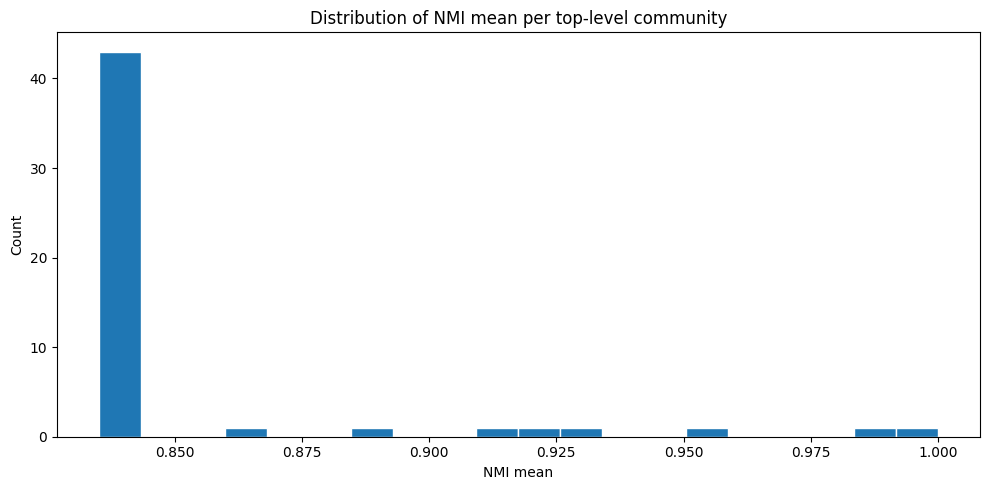

In [11]:
import matplotlib.pyplot as plt

deduped_nmi = community_summary_df.drop_duplicates(subset=['top_level_community'])

plt.figure(figsize=(10, 5))
plt.hist(deduped_nmi['nmi_mean'], bins=20, edgecolor='white')
plt.xlabel('NMI mean')
plt.ylabel('Count')
plt.title('Distribution of NMI mean per top-level community')
plt.tight_layout()
plt.show()

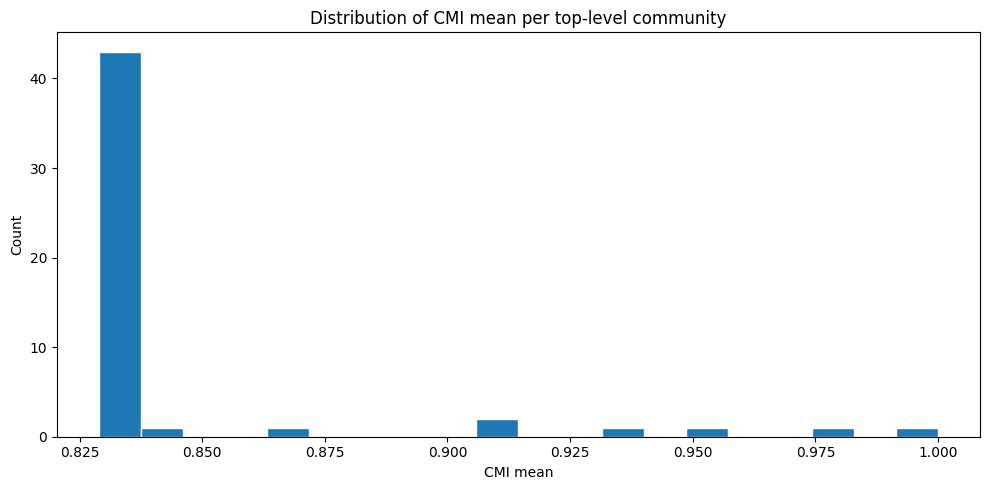

In [13]:
import matplotlib.pyplot as plt

deduped_cmi = community_summary_df.drop_duplicates(subset=['top_level_community'])

plt.figure(figsize=(10, 5))
plt.hist(deduped_nmi['cmi_mean'], bins=20, edgecolor='white')
plt.xlabel('CMI mean')
plt.ylabel('Count')
plt.title('Distribution of CMI mean per top-level community')
plt.tight_layout()
plt.show()

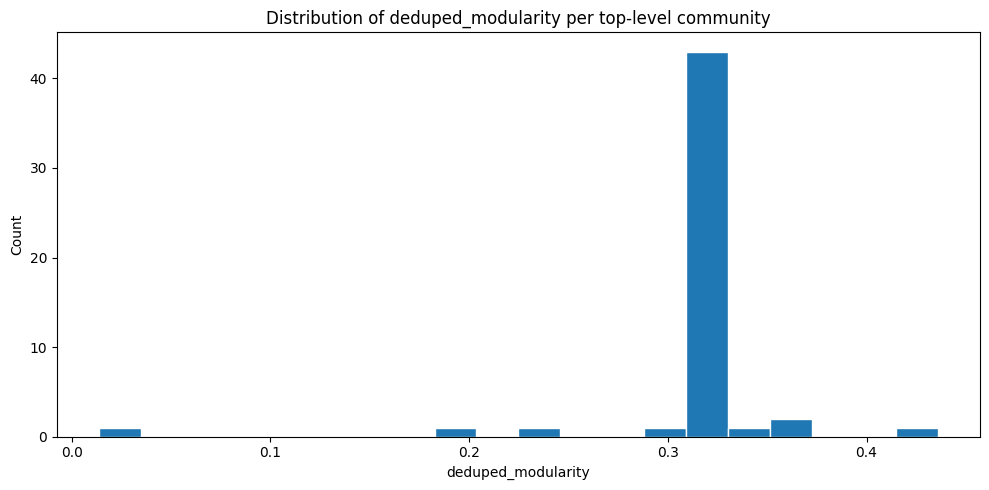

In [12]:
import matplotlib.pyplot as plt

deduped_modularity = community_summary_df.drop_duplicates(subset=['top_level_community'])

plt.figure(figsize=(10, 5))
plt.hist(deduped_modularity['modularity'], bins=20, edgecolor='white')
plt.xlabel('deduped_modularity')
plt.ylabel('Count')
plt.title('Distribution of deduped_modularity per top-level community')
plt.tight_layout()
plt.show()